# Lab 3: Actor-Critic Methods

## TDDE78 — Deep Reinforcement Learning
### Linköping University, Spring 2026

---

In this lab you will implement two fundamental **actor-critic** algorithms:
- **A2C (Advantage Actor-Critic with GAE)** — an on-policy method combining rollout-based data collection with Generalized Advantage Estimation
- **SAC (Soft Actor-Critic)** — a state-of-the-art off-policy algorithm for continuous control with entropy regularization and twin Q-networks

The lab is divided into:
- **Part A** — Implementation (fill in the TODO sections)
- **Part B** — Experiments (run systematic evaluations and analyze results)

**Instructions:** Complete all cells marked with `# TODO`. Do not modify the provided helper code unless explicitly asked.

## Setup

Run the cell below to import all necessary libraries and verify your environment.

In [1]:
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import Video, display
import warnings
warnings.filterwarnings('ignore')

# Import lab utilities
from networks import ContinuousActorCritic, SACActor, SACCritic
from utils import compute_gae, RolloutBuffer, ReplayBuffer, plot_a2c_results, plot_sac_results, plot_comparison, record_agent_video, smooth

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Resolve experiments directory relative to this notebook's location
_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f"Experiments directory: {EXPERIMENTS_DIR}")

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Using device: cuda
Experiments directory: /home/arviv790/Code/LiU/tdde78/labs/lab3_actor_critic/experiments
Setup complete!


---

# Part A — Implementation

---

## A.1 — Explore the Environment

We'll work with **LunarLanderContinuous-v3** — a continuous control task where the agent must land a spacecraft between two flags.

- **State:** 8-dimensional vector (position x/y, velocity x/y, angle, angular velocity, leg contacts)
- **Actions:** 2 continuous values — main engine thrust and side engine thrust, both in \([-1, 1]\)
- **Reward:** +100 for landing, -100 for crash, small rewards for each leg contact, penalty for using fuel
- **Solved:** Average reward ≥ 200 over 100 consecutive episodes

In [2]:
# Explore the LunarLanderContinuous environment
env = gym.make('LunarLanderContinuous-v3')

print(f"Observation space: {env.observation_space}")
print(f"  Shape: {env.observation_space.shape}")
print(f"  Low:   {env.observation_space.low}")
print(f"  High:  {env.observation_space.high}")
print()
print(f"Action space: {env.action_space}")
print(f"  Shape: {env.action_space.shape}")
print(f"  Low:   {env.action_space.low}")
print(f"  High:  {env.action_space.high}")

# Run a random episode
obs, info = env.reset(seed=42)
total_reward = 0
for step in range(1000):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

print(f"\nRandom agent — Episode length: {step+1}, Total reward: {total_reward:.1f}")
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  Shape: (8,)
  Low:   [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
  High:  [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]

Action space: Box(-1.0, 1.0, (2,), float32)
  Shape: (2,)
  Low:   [-1. -1.]
  High:  [1. 1.]

Random agent — Episode length: 154, Total reward: -74.1


## A.2 — Utility Functions (provided)

`utils.py` is **fully implemented** — you do **not** need to modify it.

It provides:
- **`compute_gae()`** — Generalized Advantage Estimation (backwards pass over the rollout)
- **`RolloutBuffer`** — on-policy buffer for A2C (stores states, actions, rewards, GAE advantages)
- **`ReplayBuffer`** — off-policy buffer for SAC (random-access replay with fixed capacity)
- **Plotting helpers** — `plot_a2c_results`, `plot_sac_results`, `plot_comparison`
- **`record_agent_video`** — records MP4 of a trained agent

Run the cells below to verify that everything works before moving on.

In [3]:
# Test compute_gae
from utils import compute_gae

# Simple 3-step example: rewards=[1,1,1], values=[0,0,0], done=[F,F,T], last_value=0
rewards    = [1.0, 1.0, 1.0]
values     = [0.0, 0.0, 0.0]
dones      = [False, False, True]
last_value = 0.0
gamma, lam = 0.99, 0.95

advs, rets = compute_gae(rewards, values, dones, last_value, gamma, lam)

assert advs.shape == (3,), f"Expected shape (3,), got {advs.shape}"
assert rets.shape  == (3,), f"Expected shape (3,), got {rets.shape}"
assert advs.dtype  == np.float32

# With lambda=1 and zero values, advantages equal MC returns
advs_mc, _ = compute_gae(rewards, values, dones, last_value, gamma, gae_lambda=1.0)
expected_G  = np.array([1 + 0.99 + 0.99**2, 1 + 0.99, 1.0], dtype=np.float32)
np.testing.assert_allclose(advs_mc, expected_G, rtol=1e-5,
                            err_msg="Lambda=1 should give MC returns")

print("compute_gae tests passed!")
print(f"  advantages (λ=0.95): {advs}")
print(f"  returns    (λ=0.95): {rets}")
print(f"  advantages (λ=1.0 ): {advs_mc}  ← should equal MC returns {expected_G}")

compute_gae tests passed!
  advantages (λ=0.95): [2.8250403 1.9405    1.       ]
  returns    (λ=0.95): [2.8250403 1.9405    1.       ]
  advantages (λ=1.0 ): [2.9701 1.99   1.    ]  ← should equal MC returns [2.9701 1.99   1.    ]


In [4]:
# Sanity-check RolloutBuffer (A2C)
from utils import RolloutBuffer

buf = RolloutBuffer(n_steps=10, state_dim=8, action_dim=2)
for i in range(10):
    buf.store(
        state    = np.zeros(8, dtype=np.float32),
        action   = np.array([0.1, -0.1], dtype=np.float32),
        reward   = 1.0,
        done     = (i == 9),
        log_prob = -1.0,
        value    = 0.5,
    )

assert len(buf) == 10, f"Expected 10, got {len(buf)}"

buf.compute_returns_and_advantages(last_value=0.0, gamma=0.99, gae_lambda=0.95)
assert buf.advantages is not None and buf.returns is not None, "advantages/returns not set"

batches = list(buf.get_batches(batch_size=5))
assert len(batches) == 2, f"Expected 2 batches, got {len(batches)}"
states, actions, old_log_probs, advantages, returns = batches[0]
assert states.shape    == (5, 8), f"states: {states.shape}"
assert actions.shape   == (5, 2), f"actions: {actions.shape}"
assert advantages.shape == (5,),  f"advantages: {advantages.shape}"

print("RolloutBuffer tests passed!")

# Sanity-check ReplayBuffer (SAC)
from utils import ReplayBuffer

rb = ReplayBuffer(capacity=1000, state_dim=8, action_dim=2, seed=42)
for i in range(100):
    rb.push(
        state      = np.zeros(8, dtype=np.float32),
        action     = np.array([0.1, -0.1], dtype=np.float32),
        reward     = 1.0,
        next_state = np.ones(8, dtype=np.float32),
        done       = False,
    )
assert len(rb) == 100

states, actions, rewards, next_states, dones = rb.sample(batch_size=32)
assert states.shape      == (32, 8), f"states: {states.shape}"
assert actions.shape     == (32, 2), f"actions: {actions.shape}"
assert rewards.shape     == (32, 1), f"rewards should be (32,1), got {rewards.shape}"
assert next_states.shape == (32, 8), f"next_states: {next_states.shape}"
assert dones.shape       == (32, 1), f"dones should be (32,1), got {dones.shape}"

print("ReplayBuffer tests passed!")

RolloutBuffer tests passed!
ReplayBuffer tests passed!


## A.3 — Network Architectures

Open `networks.py` and implement the three network classes:

**`ContinuousActorCritic`** (for A2C):
```
state_dim → 256 → Tanh → 256 → Tanh
                                    ├── → action_dim   [actor: mean μ(s)]
                                    └── → 1            [critic: V(s)]
log_std: nn.Parameter(zeros)  [learnable, shared across states]
```

**`SACActor`** (for SAC — reparameterized Gaussian with tanh squashing):
```
state_dim → 256 → ReLU → 256 → ReLU
                                     ├── → action_dim  [mean μ(s)]
                                     └── → action_dim  [log std log σ(s), clamped]
```

**`SACCritic`** (for SAC — twin Q-networks):
```
[state | action] → 256 → ReLU → 256 → ReLU → 1   (×2 independent networks)
```

In [5]:
# Test ContinuousActorCritic
from networks import ContinuousActorCritic

net = ContinuousActorCritic(state_dim=8, action_dim=2).to(device)
test_states = torch.randn(4, 8).to(device)

mean, value = net(test_states)
assert mean.shape  == (4, 2), f"mean shape: {mean.shape}"
assert value.shape == (4, 1), f"value shape: {value.shape}"

action, log_prob, entropy, value2 = net.get_action(test_states)
assert action.shape   == (4, 2), f"action shape: {action.shape}"
assert log_prob.shape == (4,),   f"log_prob shape: {log_prob.shape}"
assert entropy.shape  == (4,),   f"entropy shape: {entropy.shape}"

n_params = sum(p.numel() for p in net.parameters())
print(f"ContinuousActorCritic — parameters: {n_params:,}")
print(f"  mean: {mean.shape}, value: {value.shape}")
print("ContinuousActorCritic tests passed!")

# Test SACActor
from networks import SACActor

actor = SACActor(state_dim=8, action_dim=2).to(device)
action, log_prob = actor.get_action(test_states)
assert action.shape   == (4, 2), f"action shape: {action.shape}"
assert log_prob.shape == (4,),   f"log_prob shape: {log_prob.shape}"
assert action.abs().max().item() < 1.0, "SAC actions must be in (-1,1) after tanh"

n_params = sum(p.numel() for p in actor.parameters())
print(f"\nSACActor — parameters: {n_params:,}")
print(f"  action range: [{action.min().item():.3f}, {action.max().item():.3f}]  ← must be in (-1,1)")
print("SACActor tests passed!")

# Test SACCritic
from networks import SACCritic

critic = SACCritic(state_dim=8, action_dim=2).to(device)
test_actions = torch.randn(4, 2).to(device)
q1, q2 = critic(test_states, test_actions)
assert q1.shape == (4, 1), f"q1 shape: {q1.shape}"
assert q2.shape == (4, 1), f"q2 shape: {q2.shape}"

n_params = sum(p.numel() for p in critic.parameters())
print(f"\nSACCritic (twin) — parameters: {n_params:,}")
print(f"  q1: {q1.shape}, q2: {q2.shape}")
print("SACCritic tests passed!")

ContinuousActorCritic — parameters: 68,869
  mean: torch.Size([4, 2]), value: torch.Size([4, 1])
ContinuousActorCritic tests passed!

SACActor — parameters: 69,124
  action range: [-0.697, 0.562]  ← must be in (-1,1)
SACActor tests passed!

SACCritic (twin) — parameters: 137,730
  q1: torch.Size([4, 1]), q2: torch.Size([4, 1])
SACCritic tests passed!


## A.4 — A2C Agent

Implement the complete A2C agent. Key steps:
1. **`collect_rollout()`** — run the policy for `n_steps` steps and store transitions in `self.buffer`
2. **`update()`** — compute the A2C loss and perform one gradient update

**A2C Loss:**
$$\mathcal{L} = \underbrace{-\mathbb{E}[\log\pi_\theta(a|s) \cdot \hat{A}]}_{\text{policy loss}} + \underbrace{c_V \cdot \mathbb{E}[(V(s) - R)^2]}_{\text{value loss}} - \underbrace{c_H \cdot \mathcal{H}[\pi]}_{\text{entropy bonus}}$$

In [ ]:
class A2CAgent:
    """
    Advantage Actor-Critic (A2C) agent for continuous control.

    Collects n_steps transitions, computes GAE advantages, then performs
    one gradient update on the actor and critic simultaneously.

    Args:
        state_dim     (int):   Dimension of state space.
        action_dim    (int):   Dimension of continuous action space.
        lr            (float): Learning rate.
        gamma         (float): Discount factor.
        gae_lambda    (float): GAE lambda parameter.
        n_steps       (int):   Steps per rollout (one update per rollout).
        batch_size    (int):   Mini-batch size (unused — A2C does one full-rollout update).
        vf_coef       (float): Coefficient for value loss.
        ent_coef      (float): Coefficient for entropy bonus.
        max_grad_norm (float): Gradient clipping norm.
        seed          (int):   Random seed.
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
        n_steps: int = 2048,
        batch_size: int = 64,
        vf_coef: float = 0.5,
        ent_coef: float = 0.0,
        max_grad_norm: float = 0.5,
        seed: int = 42,
    ):
        self.gamma         = gamma
        self.gae_lambda    = gae_lambda
        self.n_steps       = n_steps
        self.batch_size    = batch_size
        self.vf_coef       = vf_coef
        self.ent_coef      = ent_coef
        self.max_grad_norm = max_grad_norm

        # =====================================================================
        # TODO: Initialize the following:
        #
        # 1. self.network   — ContinuousActorCritic(state_dim, action_dim) moved to device
        # 2. self.optimizer — Adam optimizer for self.network.parameters() with lr
        # 3. self.buffer    — RolloutBuffer(n_steps, state_dim, action_dim)
        # =====================================================================
        self.network = ContinuousActorCritic(state_dim, action_dim).to(device)
        
        self.optimizer = optim.Adam(self.network.parameters(), lr)
        
        self.buffer = RolloutBuffer(n_steps, state_dim, action_dim)

    @torch.no_grad()
    def collect_rollout(self, env, obs):
        """
        Collect n_steps transitions from the environment using the current policy.

        Args:
            env: Gymnasium environment (already reset; obs is the current state).
            obs: Current observation as numpy array of shape (state_dim,).

        Returns:
            obs:             Next observation after the rollout ends.
            last_value:      V(s_T) — bootstrapped value for the final state.
            episode_rewards: List of total rewards for any episodes completed.
        """
        self.buffer.clear()
        episode_rewards   = []
        current_ep_reward = 0.0
        last_done         = False

        # =====================================================================
        # TODO: Implement the rollout collection loop.
        #
        # For each step in range(self.n_steps):
        #   1. Convert obs to a (1, state_dim) FloatTensor on device
        #   2. Call self.network.get_action(state_t) to get action, log_prob, entropy, value
        #      - Convert action to numpy, extract scalar log_prob and value
        #   3. Step the environment: next_obs, reward, terminated, truncated, _
        #      - done = terminated or truncated
        #   4. Store the transition in self.buffer
        #   5. Track episode reward; on done append to episode_rewards and reset env
        #   6. Update obs and last_done
        #
        # After the loop, bootstrap last_value from the current policy:
        #   - If last_done is True, last_value = 0.0
        #   - Otherwise, call self.network forward to get V(obs)
        #
        # Return obs, last_value, episode_rewards
        # =====================================================================
        for i in range (self.n_steps):
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            
            action, log_prob, entropy, value = self.network.get_action(state_t)
            
            action = action.cpu().numpy()[0]
            log_prob = log_prob.item()
            value = value.item()
            
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            self.buffer.store(obs, action, reward, done, log_prob, value)
            
            current_ep_reward += reward
            if done:
                episode_rewards.append(current_ep_reward)
                current_ep_reward = 0.0
                next_obs, _ = env.reset()
                
            obs = next_obs
            last_done = done
            
        if last_done:
            last_value = 0.0
        else:
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            _, last_value = self.network.forward(state_t)
            last_value = last_value.item()
            
        return obs, last_value, episode_rewards
            
            

    def update(self):
        """
        Perform one A2C gradient update using all data stored in self.buffer.

        compute_returns_and_advantages() must be called on self.buffer BEFORE
        calling this method (done in the training loop).

        Returns:
            dict with keys 'policy_loss', 'value_loss', 'entropy'
        """
        # =====================================================================
        # TODO: Implement the A2C update (single gradient step over full rollout).
        #
        # 1. Build tensors from the buffer:
        #      states_t     = torch.FloatTensor(np.array(self.buffer.states)).to(device)
        #      actions_t    = torch.FloatTensor(np.array(self.buffer.actions)).to(device)
        #      advantages_t = torch.FloatTensor(self.buffer.advantages).to(device)
        #      returns_t    = torch.FloatTensor(self.buffer.returns).to(device)
        #
        # 2. Normalize advantages over the full rollout:
        #      advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        #
        # 3. Re-evaluate the stored actions under the CURRENT policy:
        #      _, log_probs, entropy, values = self.network.get_action(states_t, actions_t)
        #
        # 4. Compute losses:
        #      policy_loss  = -(log_probs * advantages_t).mean()
        #      value_loss   = F.mse_loss(values.squeeze(-1), returns_t)
        #      entropy_loss = -entropy.mean()
        #      total_loss   = policy_loss + self.vf_coef * value_loss + self.ent_coef * entropy_loss
        #
        # 5. Backprop + clip gradients + optimizer step
        #
        # 6. Return dict with 'policy_loss', 'value_loss', 'entropy'
        # =====================================================================
        states_t = torch.FloatTensor(np.array(self.buffer.states)).to(device)
        actions_t = torch.FloatTensor(np.array(self.buffer.actions)).to(device)
        advantages_t = torch.FloatTensor(np.array(self.buffer.advantages)).to(device)
        returns_t = torch.FloatTensor(np.array(self.buffer.returns)).to(device)
        
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        
        _, log_probs, entropy, values = self.network.get_action(states_t, actions_t)
        
        policy_loss = -(log_probs * advantages_t).mean()
        value_loss = F.mse_loss(values.squeeze(-1), returns_t)
        entropy_loss = -entropy.mean()
        total_loss = policy_loss + self.vf_coef * value_loss + self.ent_coef * entropy_loss
        
        #Backprop and optimizer step
        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
        self.optimizer.step()
        
        return {
            "policy_loss": policy_loss.item(),
            "value_loss": value_loss.item(),
            "entropy": entropy.mean().item() #mean here because we used mean for entropy loss above
        }
        

print("A2CAgent class defined!")

A2CAgent class defined!


In [ ]:
def train_a2c(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 1_000_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 10,
    **agent_kwargs,
):
    """
    Train an A2C agent and return training metrics.

    Args:
        env_name:         Gymnasium environment name.
        total_timesteps:  Total environment steps to train for.
        seed:             Random seed.
        solve_threshold:  Stop early when avg reward (last 10 episodes) >= this.
        log_interval:     Print progress every this many rollout updates.
        **agent_kwargs:   Passed to A2CAgent (e.g. gae_lambda, ent_coef).

    Returns:
        dict with keys: 'episode_rewards', 'episode_timesteps',
                        'policy_losses', 'value_losses', 'agent'
    """
    set_seed(seed)

    env = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = A2CAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    policy_losses     = []
    value_losses      = []
    global_step       = 0
    update_num        = 0

    obs, _ = env.reset(seed=seed)

    # =====================================================================
    # TODO: Implement the A2C training loop.
    #
    # while global_step < total_timesteps:
    #   1. Collect rollout:
    #        obs, last_value, ep_rewards = agent.collect_rollout(env, obs)
    #        global_step += agent.n_steps
    #
    #   2. Compute GAE advantages and value targets:
    #        agent.buffer.compute_returns_and_advantages(last_value, agent.gamma, agent.gae_lambda)
    #
    #   3. Update network (one gradient step):
    #        metrics = agent.update()
    #        update_num += 1
    #
    #   4. Record completed episode rewards:
    #        for r in ep_rewards:
    #            episode_rewards.append(r)
    #            episode_timesteps.append(global_step)
    #
    #   5. Record losses:
    #        policy_losses.append(metrics['policy_loss'])
    #        value_losses.append(metrics['value_loss'])
    #
    #   6. Log every log_interval updates (avg of last 10 episodes)
    #
    #   7. Check solve_threshold early stopping (last 10 episodes)
    # =====================================================================
    while global_step < total_timesteps:
        obs, last_value, ep_rewards = agent.collect_rollout(env, obs)
        global_step += agent.n_steps
        
        agent.buffer.compute_returns_and_advantages(last_value, agent.gamma, agent.gae_lambda)
        
        metrics = agent.update()
        update_num += 1
        
        #Record completed episode rewards
        for r in ep_rewards:
            episode_rewards.append(r)
            episode_timesteps.append(global_step)
            
        #Record losses
        policy_losses.append(metrics["policy_loss"])
        value_losses.append(metrics["value_loss"])
        
        #Log every log_interval updates
        if update_num % log_interval == 0:
            #Mean of last 10 episode rewards
            avg_reward = np.mean(episode_rewards[-10:])
            print(f"Update: {update_num} | "
                  f"Step: {global_step} | "
                  f"Avg reward (last 10): {avg_reward:.3f} | "
                  f"Policy loss: {metrics['policy_loss']:.3f} | "
                  f"Value loss: {metrics['value_loss']:.3f}")
            
        #Early stopping according to solve_threshhold
        if solve_threshold is not None and len(episode_rewards) >= 10:
            avg_reward = np.mean(episode_rewards[-10:])
            
            if avg_reward >= solve_threshold:
                print(f"Solved at step {global_step} with average reward {avg_reward:.3f}!")
                break
            
            
    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'policy_losses':     policy_losses,
        'value_losses':      value_losses,
        'agent':             agent,
    }

print("train_a2c defined!")

train_a2c defined!


## A.5 — SAC Agent

Implement the complete SAC agent. Key steps:
1. **`select_action()`** — stochastic action for training, deterministic (`tanh(mean)`) for evaluation
2. **`update()`** — one full SAC gradient update covering critic, actor, temperature, and soft target networks

**SAC Objectives:**

Critic (Bellman backup with clipped double-Q):
$$y = r + \gamma(1-d)\bigl[\min_i Q_{\phi_i}^{\text{targ}}(s', a') - \alpha \log\pi(a'|s')\bigr]$$

Actor (maximize Q − entropy penalty):
$$\mathcal{L}_\pi = \mathbb{E}\bigl[\alpha \log\pi(a|s) - \min_i Q_{\phi_i}(s, a)\bigr]$$

Temperature (match target entropy $\bar{\mathcal{H}}$):
$$\mathcal{L}_\alpha = -\alpha \cdot \bigl(\log\pi(a|s) + \bar{\mathcal{H}}\bigr)$$

In [10]:
class SACAgent:
    """
    Soft Actor-Critic (SAC) agent for continuous control.

    Uses:
    - SACActor: outputs mean and log_std; samples via reparameterisation
    - SACCritic: twin Q-networks (clipped double-Q trick)
    - SACCritic (target): slow-moving copy for stable Bellman targets
    - ReplayBuffer: uniform off-policy experience replay
    - Automatic entropy tuning (optional): learns α to match target entropy
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        tau: float = 0.005,
        alpha: float = -2.3,
        autotune_alpha: bool = True,
        target_entropy: float = None,
        buffer_size: int = 1_000_000,
        batch_size: int = 256,
        learning_starts: int = 5000,
        train_frequency: int = 1,
        seed: int = 42,
    ):
        self.gamma           = gamma
        self.tau             = tau
        self.batch_size      = batch_size
        self.learning_starts = learning_starts
        self.train_frequency = train_frequency
        self.autotune_alpha  = autotune_alpha

        # TODO: Instantiate actor, twin critics, and target critic
        #   self.actor         = SACActor(state_dim, action_dim).to(device)
        #   self.critic        = SACCritic(state_dim, action_dim).to(device)
        #   self.critic_target = SACCritic(state_dim, action_dim).to(device)
        #   Copy critic weights into critic_target and set critic_target.eval()
        self.actor = SACActor(state_dim, action_dim).to(device)
        self.critic = SACCritic(state_dim, action_dim).to(device)
        self.critic_target = SACCritic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_target.eval()

        # TODO: Create Adam optimizers for actor and critic
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        
        # TODO: Create a ReplayBuffer(buffer_size, state_dim, action_dim, seed)
        self.replay_buffer = ReplayBuffer(buffer_size, state_dim, action_dim, seed)

        # TODO: Entropy temperature setup
        #   if autotune_alpha:
        #       self.target_entropy  = float(target_entropy) if target_entropy is not None else -action_dim
        #       self.log_alpha       = torch.zeros(1, requires_grad=True, device=device)
        #       self.alpha           = self.log_alpha.exp().item()
        #       self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
        #   else:
        #       self.alpha = alpha
        if autotune_alpha:
            self.target_entropy = float(target_entropy) if target_entropy is not None else -action_dim
            self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
            self.alpha = self.log_alpha.exp().item()
            self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
        else:
            self.alpha = alpha

    def select_action(self, state, deterministic=False):
        """Select an action (stochastic during training, deterministic for eval)."""
        # TODO: Convert state to tensor, forward through actor
        #   deterministic=True  → tanh(mean)
        #   deterministic=False → actor.get_action(state_t)
        # Return action as a numpy array (shape: [action_dim])
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        if deterministic:
            mean, _ = self.actor(state_t)
            action = torch.tanh(mean)
        else:
            action, _ = self.actor.get_action(state_t)
            
        return action.detach().cpu().numpy()[0]
            
        
    def update(self):
        """One full SAC gradient update (critic + actor + temperature + soft target)."""
        # Step 1: Sample a batch from the replay buffer and move to device
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        next_states = next_states.to(device)
        dones = dones.to(device)

        # Step 2: Critic update
        # TODO: Compute Bellman target y using critic_target + actor:
        #   next_actions, next_log_pi = self.actor.get_action(next_states)
        #   q1_next, q2_next = self.critic_target(next_states, next_actions)
        #   min_q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_pi.unsqueeze(-1)
        #   y = rewards + self.gamma * (1 - dones) * min_q_next
        
        #We do NOT want to track gradients for target network
        with torch.no_grad():
            next_actions, next_log_pi = self.actor.get_action(next_states)
            
            q1_next, q2_next = self.critic_target(next_states, next_actions)
            
            min_q_next = torch.min(q1_next, q2_next) -self.alpha * next_log_pi.unsqueeze(-1)
            
            y = rewards + self.gamma * (1 - dones) * min_q_next
        
        # TODO: Compute critic loss = MSE(q1, y) + MSE(q2, y) and update critic
        #Now that we're going to update the actual critic and not critic_target we track gradients again
        q1, q2 = self.critic(states, actions)
        
        critic_loss = (F.mse_loss(q1, y) + F.mse_loss(q2, y))
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Step 3: Actor update
        # TODO: Sample new actions from the current policy and compute:
        #   actor_loss = mean(alpha * log_pi - min(q1_pi, q2_pi))
        new_actions, log_pi = self.actor.get_action(states)
        q1_pi, q2_pi = self.critic(states, new_actions)
        
        actor_loss = torch.mean(self.alpha * log_pi - torch.min(q1_pi, q2_pi).squeeze(-1))
        
        # TODO: Update actor optimizer
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        # Step 4: Temperature (alpha) update — only if autotune_alpha=True
        # TODO: alpha_loss = mean(-log_alpha.exp() * (log_pi + target_entropy))
        if self.autotune_alpha: #Detach log_pi because it's connected to actor graph, but we're optimizing for alpha now
            alpha_loss = torch.mean(-self.log_alpha.exp() * (log_pi + self.target_entropy).detach())
        
        # TODO: Update alpha_optimizer and refresh self.alpha = log_alpha.exp().item()
            self.alpha_optimizer.zero_grad()
            alpha_loss.backward()
            self.alpha_optimizer.step()
            self.alpha = self.log_alpha.exp().item()
            
        else: #If we run in autotune_alpha=False mode, alpha is just a constant --> loss = 0
            alpha_loss = torch.tensor(0.0)

        # Step 5: Soft target update (Polyak averaging)
        # TODO: For each (param, target_param) pair:
        #   target_param.data = tau * param.data + (1 - tau) * target_param.data
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data[:] = self.tau * param.data + (1 - self.tau) * target_param.data 

        return {
            'critic_loss': critic_loss.item(),
            'actor_loss':  actor_loss.item(),
            'alpha_loss':  alpha_loss.item(),
            'alpha':       self.alpha,
        }

print("SACAgent class defined!")

SACAgent class defined!


In [7]:
def train_sac(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 300_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 5000,
    **agent_kwargs,
):
    """
    Train a SAC agent and return training metrics.

    Args:
        env_name:         Gymnasium environment name.
        total_timesteps:  Total environment steps.
        seed:             Random seed.
        solve_threshold:  Stop early when avg reward (last 10 episodes) >= this.
        log_interval:     Print progress every this many environment steps.
        **agent_kwargs:   Passed to SACAgent.

    Returns:
        dict with keys: 'episode_rewards', 'episode_timesteps',
                        'critic_losses', 'actor_losses', 'alpha_history', 'agent'
    """
    set_seed(seed)

    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = SACAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    critic_losses     = []
    actor_losses      = []
    alpha_history     = []

    # =====================================================================
    # TODO: Implement the SAC training loop.
    #
    # obs, _ = env.reset(seed=seed)
    # current_ep_reward = 0.0
    # next_log = log_interval
    obs, _ = env.reset(seed=seed)
    current_ep_reward = 0.0
    next_log = log_interval
    
    # for global_step in range(1, total_timesteps + 1):
    for global_step in range(1, total_timesteps + 1):
    
        #   1. Select action:
        #        if global_step < agent.learning_starts:
        #            action = env.action_space.sample()   # random warm-up
        #        else:
        #            action = agent.select_action(obs)    # policy action
        if global_step < agent.learning_starts:
            action = env.action_space.sample()
        else:
            action = agent.select_action(obs)
        
        #   2. Step the environment; compute done = terminated or truncated
        #      Store ONLY terminated as real_done (not truncated) to avoid
        #      incorrect bootstrapping at episode boundaries
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        real_done = terminated
        
        #   3. Push transition to replay buffer; accumulate episode reward
        agent.replay_buffer.push(obs, action, reward, next_obs, real_done)
        current_ep_reward += float(reward)
        
        #   4. On done: record episode_rewards and episode_timesteps, reset env
        if done:
            episode_rewards.append(current_ep_reward)
            episode_timesteps.append(global_step)
            current_ep_reward = 0.0    
            next_obs, _ = env.reset()
            
        obs = next_obs
        
        #   5. Gradient update (after learning_starts, every train_frequency steps,
        #      when replay buffer has enough samples):
        #        metrics = agent.update()
        #        append to critic_losses, actor_losses, alpha_history
        if global_step >= agent.learning_starts and global_step % agent.train_frequency == 0 and len(agent.replay_buffer) >= agent.batch_size:
            
            metrics = agent.update()
            critic_losses.append(metrics["critic_loss"])
            actor_losses.append(metrics["actor_loss"])
            alpha_history.append(metrics["alpha"])
        
        #   6. Logging every log_interval steps:
        #        avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
        #        print step, avg_reward, agent.alpha
        if global_step >= next_log:
            avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
            print(f"Step: {global_step} | Avg reward (last 10): {avg_reward:.3f} | Alpha: {agent.alpha:.3f}")
            next_log += log_interval
        
        #   7. Check solve_threshold early stopping (based on last 10 episodes)
        # =====================================================================
        if solve_threshold is not None and len(episode_rewards) >= 10:
            avg_reward = np.mean(episode_rewards[-10:])
            
            if avg_reward >= solve_threshold:
                print(f"Solved at step {global_step} with average reward {avg_reward:.3f}!")
                break

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'critic_losses':     critic_losses,
        'actor_losses':      actor_losses,
        'alpha_history':     alpha_history,
        'agent':             agent,
    }


def evaluate_greedy(agent, env, num_episodes=10, seed=0):
    """Evaluate a SAC agent deterministically (no exploration noise)."""
    rewards = []
    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_reward = 0
        for _ in range(10000):
            action = agent.select_action(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            if terminated or truncated:
                break
        rewards.append(ep_reward)
    return np.mean(rewards)


print("train_sac and evaluate_greedy defined!")

train_sac and evaluate_greedy defined!


Update: 10 | Step: 20480 | Avg reward (last 10): -213.647 | Policy loss: -0.009 | Value loss: 1412.564
Update: 20 | Step: 40960 | Avg reward (last 10): -185.429 | Policy loss: 0.012 | Value loss: 1846.444
Update: 30 | Step: 61440 | Avg reward (last 10): -152.579 | Policy loss: -0.001 | Value loss: 1350.245
Update: 40 | Step: 81920 | Avg reward (last 10): -176.411 | Policy loss: 0.030 | Value loss: 912.673
Update: 50 | Step: 102400 | Avg reward (last 10): -136.550 | Policy loss: -0.027 | Value loss: 1167.369
Update: 60 | Step: 122880 | Avg reward (last 10): -159.146 | Policy loss: -0.008 | Value loss: 1259.059
Update: 70 | Step: 143360 | Avg reward (last 10): -172.496 | Policy loss: -0.005 | Value loss: 1062.651
Update: 80 | Step: 163840 | Avg reward (last 10): -197.175 | Policy loss: -0.023 | Value loss: 1226.482
Update: 90 | Step: 184320 | Avg reward (last 10): -172.305 | Policy loss: 0.013 | Value loss: 1249.128
Update: 100 | Step: 204800 | Avg reward (last 10): -206.521 | Policy los

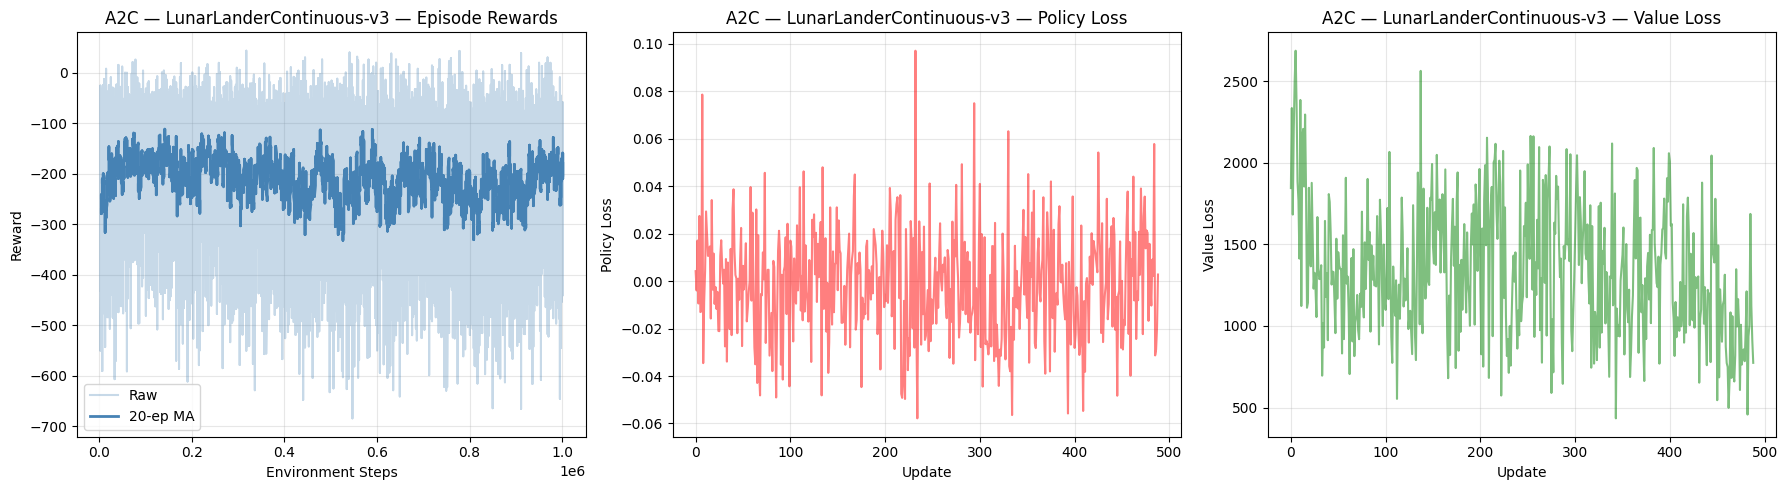


Average reward (last 50 episodes): -192.7


In [13]:
# A.6 — Train A2C on LunarLanderContinuous-v3
# Expected behaviour: A2C struggles — reward typically stays around -150 to -200.
# That is normal; the point is to observe the training dynamics before moving to SAC.
results_a2c = train_a2c(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 1_000_000,
    n_steps         = 2048,
    batch_size      = 64,
    lr              = 3e-4,
    gae_lambda      = 0.95,
    ent_coef        = 0.01,
    solve_threshold = 200.0,
    seed            = 42,
    log_interval    = 10,
)

plot_a2c_results(results_a2c,
                 title="A2C — LunarLanderContinuous-v3",
                 experiments_dir=EXPERIMENTS_DIR)

last_ep = results_a2c['episode_rewards'][-50:]
print(f"\nAverage reward (last 50 episodes): {np.mean(last_ep):.1f}")

In [22]:
# A.6 — Visualize the trained A2C agent
video_path = record_agent_video(
    results_a2c['agent'],
    env_name        = "LunarLanderContinuous-v3",
    agent_type      = "a2c",
    num_episodes    = 3,
    seed            = 0,
    name_prefix     = "a2c_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

Episode 1: reward = -119.1
Episode 2: reward = -152.4
Episode 3: reward = -115.8
Video saved → /home/arviv790/Code/LiU/tdde78/labs/lab3_actor_critic/experiments/videos/a2c_lunar-episode-2.mp4


Step: 10000 | Avg reward (last 10): -130.668 | Alpha: 0.173
Step: 20000 | Avg reward (last 10): -18.923 | Alpha: 0.106
Step: 30000 | Avg reward (last 10): -142.161 | Alpha: 0.104
Step: 40000 | Avg reward (last 10): 0.906 | Alpha: 0.135
Step: 50000 | Avg reward (last 10): 86.692 | Alpha: 0.141
Step: 60000 | Avg reward (last 10): 117.771 | Alpha: 0.110
Solved at step 64059 with average reward 214.193!
Plot saved → /home/arviv790/Code/LiU/tdde78/labs/lab3_actor_critic/experiments/plots/sac__lunarlandercontinuous-v3.png


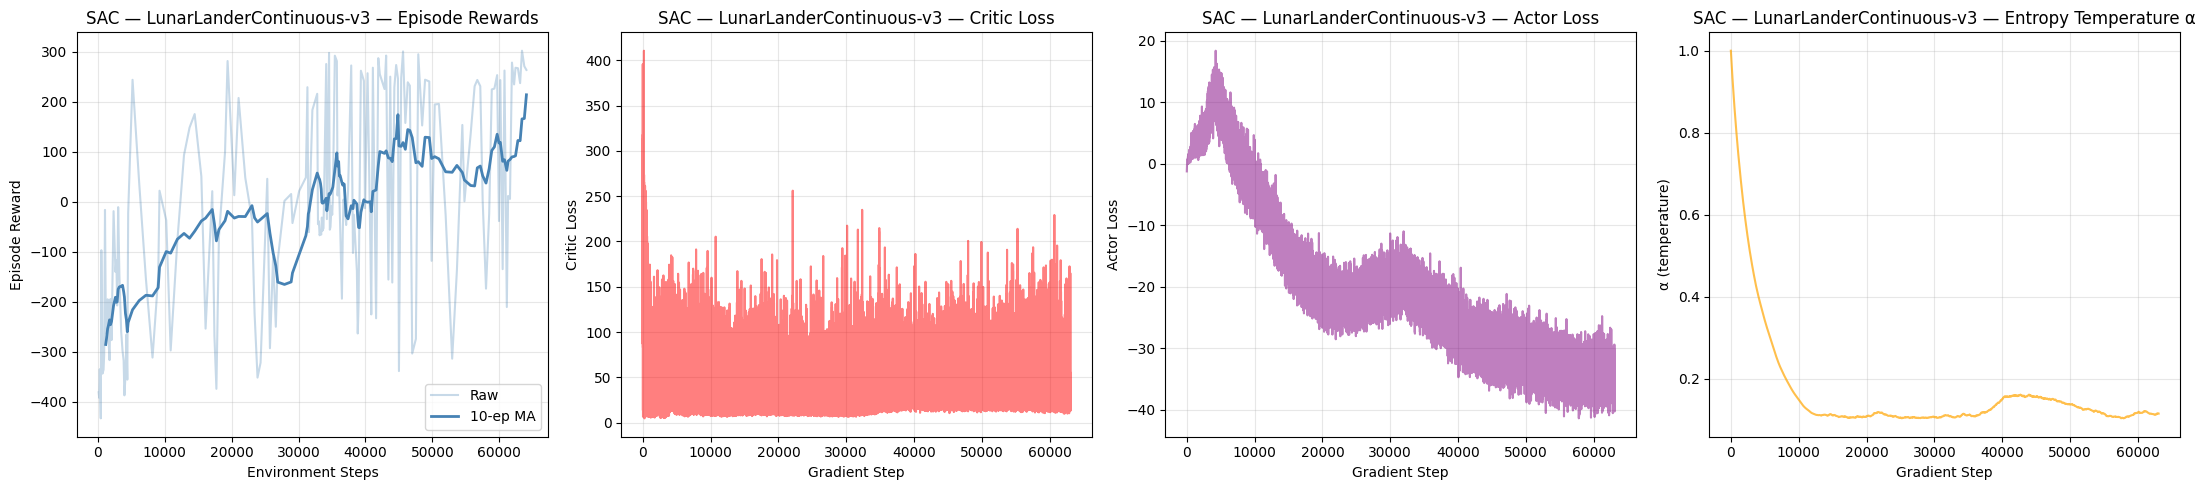


Average reward (last 10 episodes): 214.2
LunarLander SOLVED with SAC!


In [11]:
# A.7 — Train SAC on LunarLanderContinuous-v3
# Expected: SAC solves the environment in ~40k-50k steps (reward ≥ 200).
results_sac = train_sac(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 300_000,
    learning_starts = 1000,
    batch_size      = 256,
    lr              = 3e-4,
    tau             = 0.005,
    gamma           = 0.99,
    autotune_alpha  = True,
    solve_threshold = 200.0,
    seed            = 42,
    log_interval    = 10_000,
)

plot_sac_results(results_sac,
                 title="SAC — LunarLanderContinuous-v3",
                 experiments_dir=EXPERIMENTS_DIR)

last_ep = results_sac['episode_rewards'][-10:]
print(f"\nAverage reward (last 10 episodes): {np.mean(last_ep):.1f}")
if np.mean(last_ep) >= 200:
    print("LunarLander SOLVED with SAC!")

In [12]:
# A.7 — Visualize the trained SAC agent
video_path = record_agent_video(
    results_sac['agent'],
    env_name        = "LunarLanderContinuous-v3",
    agent_type      = "sac",
    num_episodes    = 3,
    seed            = 0,
    name_prefix     = "sac_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

Episode 1: reward = 244.7
Episode 2: reward = 194.4
Episode 3: reward = 199.9
Video saved → /home/arviv790/Code/LiU/tdde78/labs/lab3_actor_critic/experiments/videos/sac_lunar-episode-2.mp4


---

# Part B — Experiments

For all experiments, run at least **3 random seeds** and report mean ± std.

---

## B.1 — Ablation: SAC Entropy Temperature

The entropy temperature α controls the exploration-exploitation trade-off in SAC.
Compare three settings: fixed α = 0.05 (low entropy), fixed α = 0.2 (moderate), and
auto-tuned α which adapts throughout training to match a target entropy level.

**Expected finding:** Auto-tuning should outperform fixed values because it provides
high exploration early and naturally decays as the policy converges.

Step: 5000 | Avg reward (last 10): -220.772 | Alpha: 0.050
Step: 10000 | Avg reward (last 10): -221.960 | Alpha: 0.050
Step: 15000 | Avg reward (last 10): -238.256 | Alpha: 0.050
Step: 20000 | Avg reward (last 10): -269.877 | Alpha: 0.050
Step: 25000 | Avg reward (last 10): -90.269 | Alpha: 0.050
Step: 30000 | Avg reward (last 10): -31.334 | Alpha: 0.050
Step: 35000 | Avg reward (last 10): -41.744 | Alpha: 0.050
Step: 40000 | Avg reward (last 10): -18.223 | Alpha: 0.050
Step: 45000 | Avg reward (last 10): -32.961 | Alpha: 0.050
Step: 50000 | Avg reward (last 10): -27.804 | Alpha: 0.050
Step: 55000 | Avg reward (last 10): -10.409 | Alpha: 0.050
Step: 60000 | Avg reward (last 10): -27.888 | Alpha: 0.050
Step: 65000 | Avg reward (last 10): -32.234 | Alpha: 0.050
Step: 70000 | Avg reward (last 10): -25.312 | Alpha: 0.050
Step: 75000 | Avg reward (last 10): -29.954 | Alpha: 0.050
Step: 80000 | Avg reward (last 10): -47.114 | Alpha: 0.050
Step: 85000 | Avg reward (last 10): -50.541 | Alpha: 

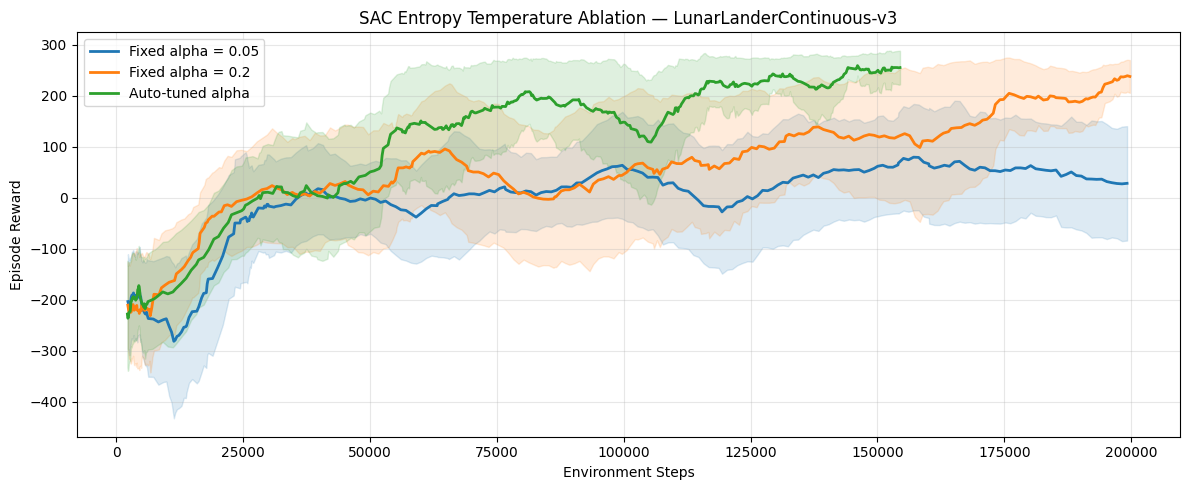


Mean ± Std of average reward (last 20 episodes):
  Fixed alpha = 0.05: 140.4 ± 103.5
  Fixed alpha = 0.2: 250.2 ± 13.9
  Auto-tuned alpha: 252.9 ± 20.8


In [13]:
# B.1 — SAC entropy temperature ablation (3 seeds each)
seeds = [42, 123, 456]

entropy_results = {
    'Fixed alpha = 0.05': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.05, seed=s,
        )
        for s in seeds
    ],
    'Fixed alpha = 0.2': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.2, seed=s,
        )
        for s in seeds
    ],
    'Auto-tuned alpha': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=True, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(entropy_results,
                title="SAC Entropy Temperature Ablation — LunarLanderContinuous-v3",
                experiments_dir=EXPERIMENTS_DIR)

print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in entropy_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

## B.2 — Ablation: GAE Lambda in A2C

GAE lambda λ interpolates between one-step TD (λ = 0, low variance, high bias)
and Monte Carlo returns (λ = 1, no bias, high variance). Compare λ = 0.0, λ = 0.95
(default), and λ = 1.0 to observe the bias-variance trade-off in practice.

**Note:** Since A2C already struggles on this environment, differences between
λ values may be subtle — focus on any systematic trends across seeds.

Update: 10 | Step: 20480 | Avg reward (last 10): -297.863 | Policy loss: -0.019 | Value loss: 109.906
Update: 20 | Step: 40960 | Avg reward (last 10): -247.431 | Policy loss: -0.006 | Value loss: 95.597
Update: 30 | Step: 61440 | Avg reward (last 10): -221.737 | Policy loss: 0.037 | Value loss: 102.624
Update: 40 | Step: 81920 | Avg reward (last 10): -332.976 | Policy loss: 0.014 | Value loss: 78.442
Update: 50 | Step: 102400 | Avg reward (last 10): -198.742 | Policy loss: -0.040 | Value loss: 86.616
Update: 60 | Step: 122880 | Avg reward (last 10): -181.046 | Policy loss: -0.035 | Value loss: 83.912
Update: 70 | Step: 143360 | Avg reward (last 10): -285.612 | Policy loss: 0.024 | Value loss: 90.191
Update: 80 | Step: 163840 | Avg reward (last 10): -272.716 | Policy loss: -0.046 | Value loss: 77.772
Update: 90 | Step: 184320 | Avg reward (last 10): -271.734 | Policy loss: 0.013 | Value loss: 76.264
Update: 100 | Step: 204800 | Avg reward (last 10): -366.658 | Policy loss: 0.036 | Value

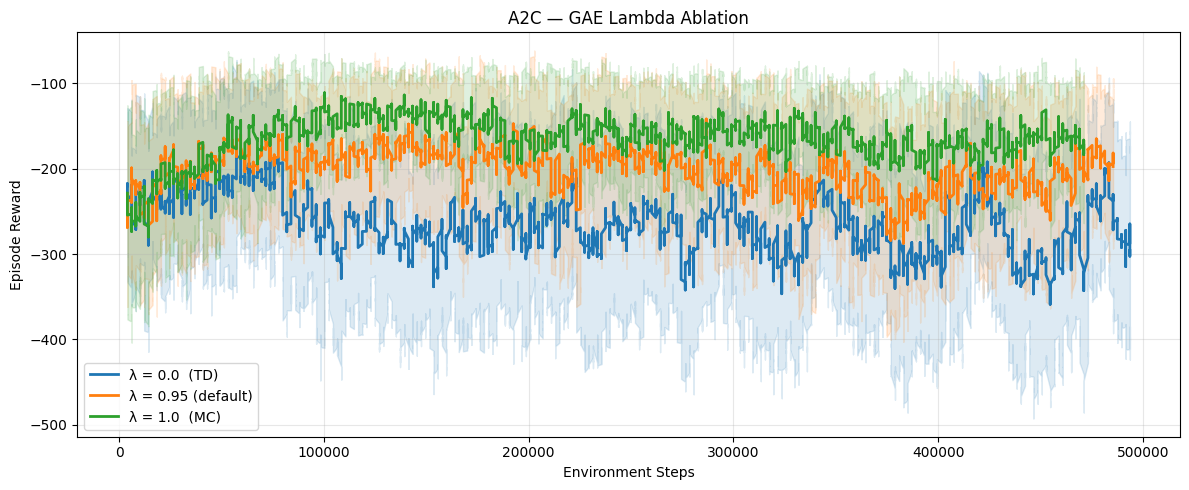


Mean ± Std of average reward (last 20 episodes):
  λ = 0.0  (TD): -278.3 ± 4.2
  λ = 0.95 (default): -225.5 ± 32.5
  λ = 1.0  (MC): -166.7 ± 31.0


In [15]:
# B.2 — GAE lambda ablation in A2C (3 seeds each)
seeds = [42, 123, 456]

lambda_results = {
    'λ = 0.0  (TD)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.0, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
    'λ = 0.95 (default)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.95, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
    'λ = 1.0  (MC)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=1.0, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(lambda_results,
                title="A2C — GAE Lambda Ablation",
                experiments_dir=EXPERIMENTS_DIR)

print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in lambda_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

---

## Summary

**TODO:** Write a brief summary of your findings (double-click to edit).

1. **A.6/A.7 — A2C vs SAC:** Describe the difference in learning behaviour between A2C and SAC on LunarLanderContinuous-v3. Which algorithm solves the environment, and approximately how many environment steps does it take?

SAC had much faster and more stable learning than A2C in LunarLanderContinous. For A2C the rewards were basically only negative throughout all the training and the learning curves in the graph are very up and down. SAC showed much clearer learning progress by starting with high negative values and then consistently performing above 200 average reward. One of the main reasons for this I would suspect is the difference that A2C is on-policy making it only learn from new experiences. SAC on the other hand is off-policy and it's use of the replay buffer during training makes it able to learn from past experiences as well. This seems to make SAC much better at learning how to navigate complex and continous environments like in this lab. Entropy is also used as a goal during SAC training which encourages this model to explore naturally, while A2C doesn't have this exploration encouragement built into the model which may have reduced performance here. For SAC it varied a lot between seeds, but for some seeds it reached the average reward within 60k steps, while A2C didn't even come close to the solve threshhold.



2. **B.1 — SAC entropy temperature:** Which α setting performed best? Describe how the entropy temperature affects exploration and why auto-tuning outperforms fixed values.

Both auto-tuning of α and the fixed setting of α = 0.2 performed very well. The fixed α = 0.2 gave lower variance with slightly lower average reward compared to the auto-tuned α making them roughly equal when it comes to performance. In contrast, the fixed α = 0.05 gave poor results with much lower average reward and much higher variance. According to this, it seems like making SAC more deterministic generally leads to poor performance. To have a higher α and encourage entropy in the model generally leads to better learning and better final performance. Unlike models we have coded before with hardcoded exploration, SAC learns better when we encourage entropy/exploration to a certain extent.



3. **B.2 — GAE lambda in A2C:** Which λ value worked best? Describe the bias-variance trade-off — what happens at the extremes (λ = 0 and λ = 1)?

Even though none of the models performed well, it is clear that the Monte Carlo setting with λ = 1.0 performed the best. The TD setting of λ = 0.0 performed the worst and didn't seem to learn how to navigate the environment. With low λ values we rely very much on bootstrapping from the critic, and even though we get lower variance we also get higher bias which was very clear here. In contrast, using higher λ values (like Monte Carlo) makes the model look at long-term returns which reduces the bias but increases variance in advantage estimates. As we can see in the results this clearly increased performance in the A2C model for this environment, and it was more important here to reduce bias than it was to lower the variance in advantage estimates.

---

**Lab designed by Amath Sow:** [amath.sow@liu.se](mailto:amath.sow@liu.se)

**TDDE78 — Deep Reinforcement Learning, Linköping University — Spring 2026**